# EDA (Exploratory Data Analysis)

Esta EDA funciona para para descubrir patrones y problemas iniciales:
- Resúmenes estadísticos.
- Visualizaciones iniciales para identificar tendencias o anomalías.
- Correlaciones entre variables.

In [ ]:
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Cargar la base de datos

In [ ]:
# Conectar con MySQL utilizando sqlalchemy

# El URL de la base de datos desde MySQL Server
host = '212.227.90.6'
database = 'Equip_22'
user = 'Equipo22'
password = 'E1q2u3i4p5o22'

# Crear la conexión
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")
connection = engine.connect()

# Cargar la tabla Tourist_Accommodation como un df
df = pd.read_sql_table('Tourist_Accommodation', connection)

# Cerrar la conexión
connection.close()

2. Información general de la tabla

In [35]:
# Un vistazo a la tabla con los primeros registros
df.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,None,Private room,2,2,1,...,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1,1,...,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2,...,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2,1,...,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,None,Private room,5,1,2,...,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


In [ ]:
# Revisar información de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7001 entries, 0 to 7000
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 7001 non-null   int64  
 1   name                         6998 non-null   object 
 2   description                  6972 non-null   object 
 3   host_id                      7001 non-null   int64  
 4   neighbourhood_name           7001 non-null   object 
 5   neighbourhood_district       4241 non-null   object 
 6   room_type                    7001 non-null   object 
 7   accommodates                 7001 non-null   int64  
 8   bathrooms                    6969 non-null   object 
 9   bedrooms                     6972 non-null   object 
 10  beds                         6998 non-null   float64
 11  amenities_list               6984 non-null   object 
 12  price                        6870 non-null   float64
 13  minimum_nights    

3. Descripción estadística

In [ ]:
# Resumen estadístico de las columnas numéricas
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
apartment_id,7001.0,1.511978e+07,7.715578e+06,11964.0,8749646.0,16737061.0,21463214.0,27245117.0
host_id,7001.0,6.218673e+07,5.747094e+07,10704.0,10500150.0,42613804.0,106289587.0,336524176.0
accommodates,7001.0,4.351807e+00,2.620646e+00,1.0,2.0,4.0,6.0,29.0
beds,6998.0,3.013575e+00,2.330849e+00,0.0,1.0,2.0,4.0,30.0
price,6870.0,1.011098e+03,8.459754e+02,60.0,450.0,750.0,1230.0,6071.0
minimum_nights,7001.0,4.424939e+00,1.066957e+01,1.0,1.0,2.0,4.0,365.0
maximum_nights,7001.0,7.594676e+02,4.979648e+02,1.0,70.0,1125.0,1125.0,1125.0
availability_30,7001.0,1.227739e+01,1.151080e+01,0.0,0.0,10.0,24.0,30.0
availability_60,7001.0,2.741994e+01,2.241343e+01,0.0,2.0,26.0,50.0,60.0
availability_90,7001.0,4.430667e+01,3.301718e+01,0.0,9.0,46.0,76.0,90.0


In [8]:
# Resumen estadístico de las columnas no numéricas
df.describe(include = object).transpose()

,count,unique,top,freq
name,6998,6755,Beautiful two bedroom appartment with comunita...,4
description,6972,6790,This apartment is part of a nice and well kept...,4
neighbourhood_name,7001,478,la Dreta de l'Eixample,262
neighbourhood_district,4241,61,Eixample,786
room_type,7001,4,Entire home/apt,4979
bathrooms,6969,13,1,4144
bedrooms,6972,14,1,3141
amenities_list,6984,6792,"TV,Wifi,Air conditioning,Kitchen,Elevator,Heat...",9
has_availability,6451,1,VERDADERO,6451
first_review_date,5747,1793,01/04/2018,27


4. Visualización sencilla por cada columna

In [ ]:
# Sleccionar las columnas no necessarias para la visualización por cada columna,
# porque o (1) no tiene sendido hacerlo,
# o (2) tienen demasidas categorias que no nos interesan de momento
cols_excluir = ["apartment_id", "name", "description", "host_id",
                "neighbourhood_name", "neighbourhood_district", "amenities_list",
                "first_review_date", "last_review_date", "reviews_per_month", "insert_date"]

4.1 Visualización: histplots de las columnas numéricas

In [55]:
# sleccionar las columnas numéricas
cols_num = df.select_dtypes(include='number').columns
cols_num = [x for x in cols_num if x not in cols_excluir]

# Cuántas columnas?
print(len(cols_num), "columnas numéricas para visualizar.")

17 columnas numéricas para visualizar.


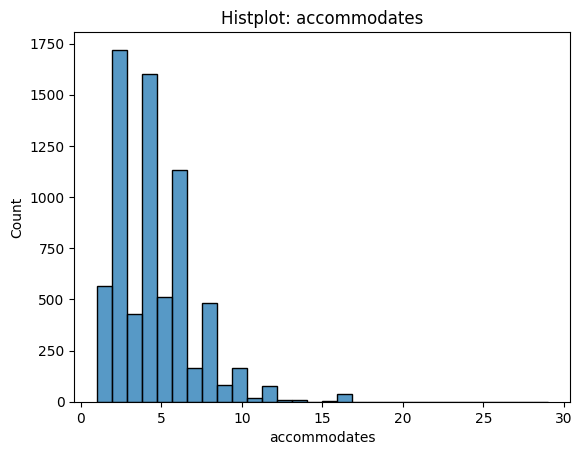

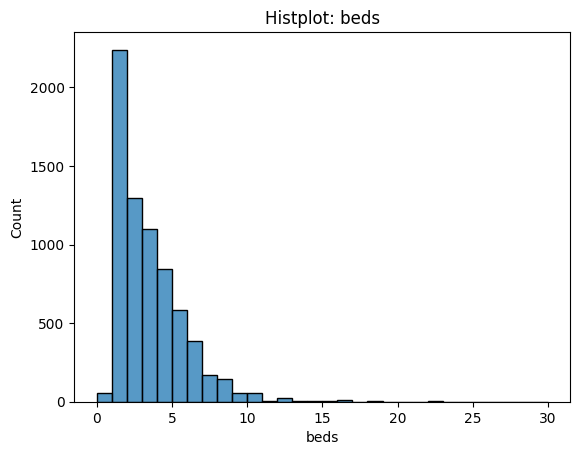

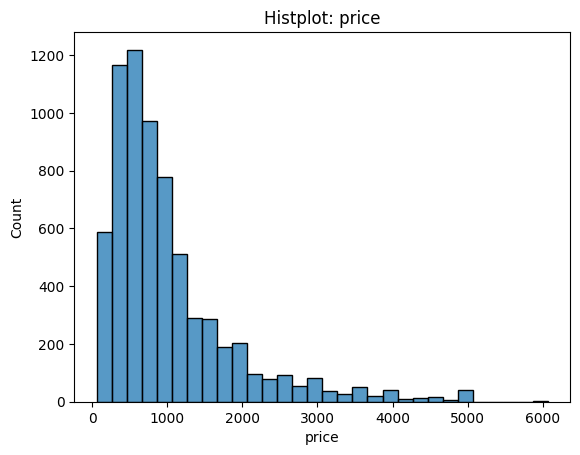

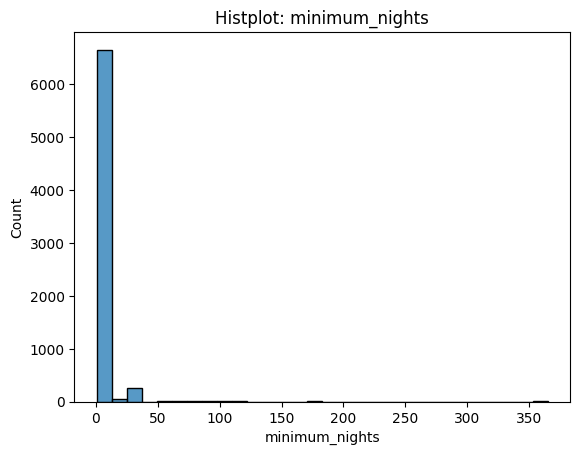

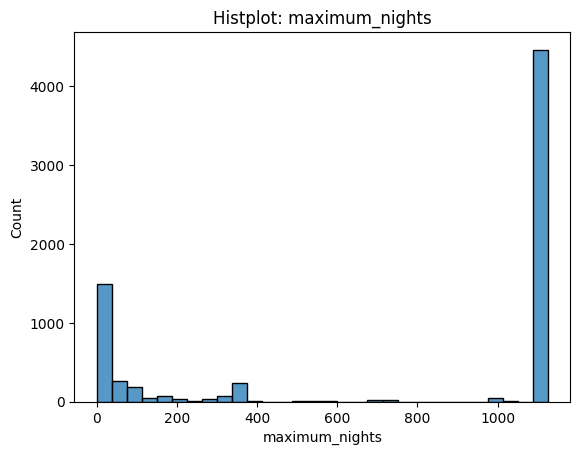

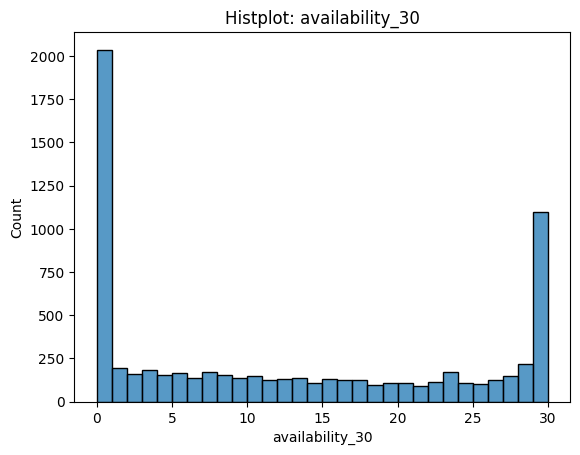

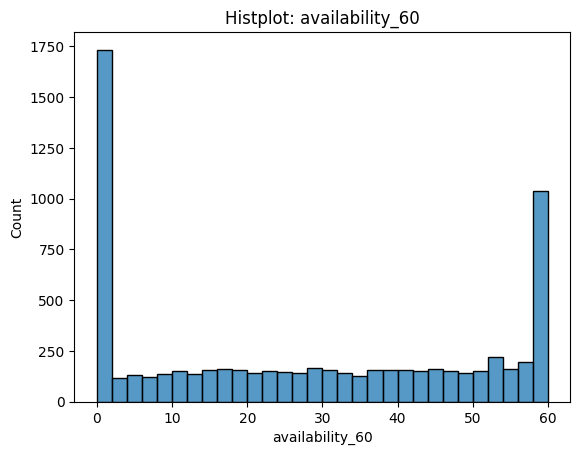

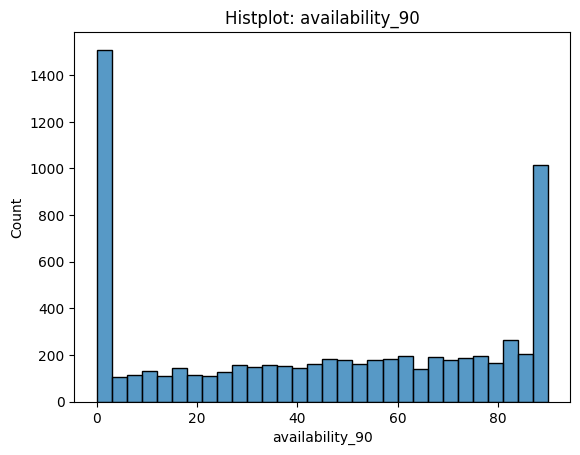

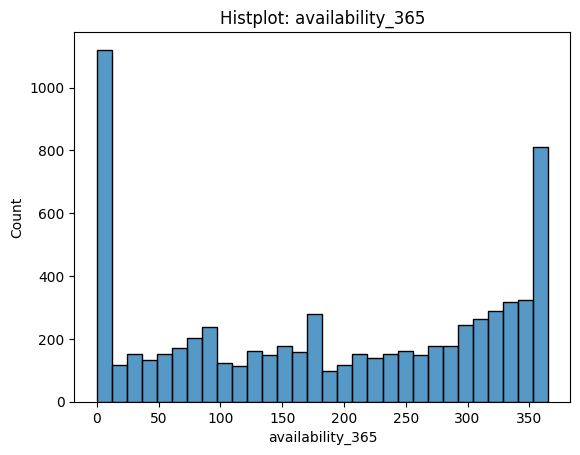

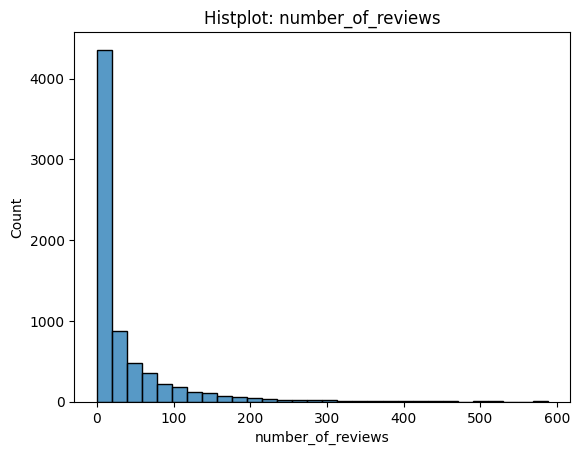

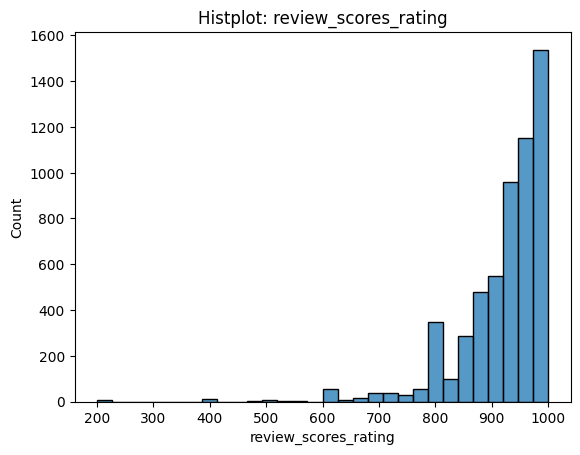

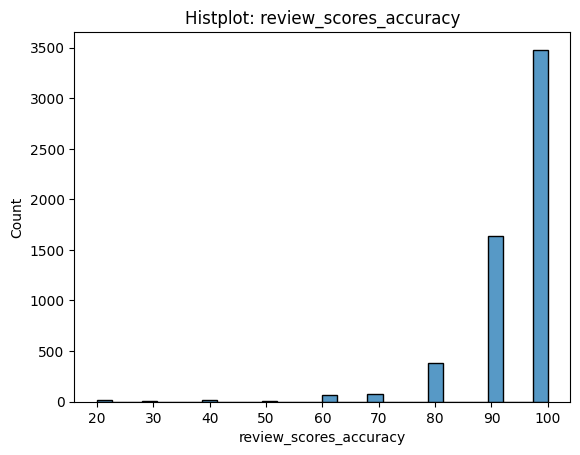

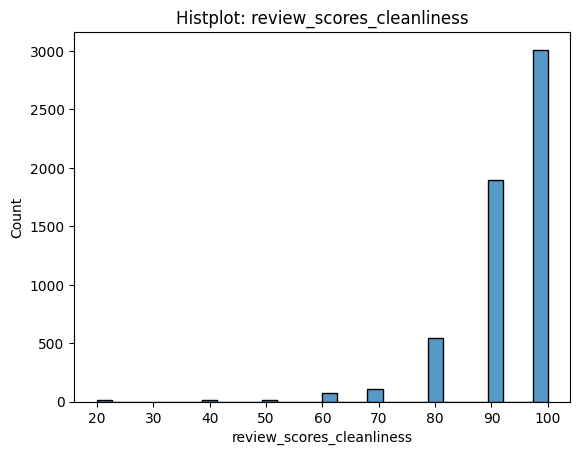

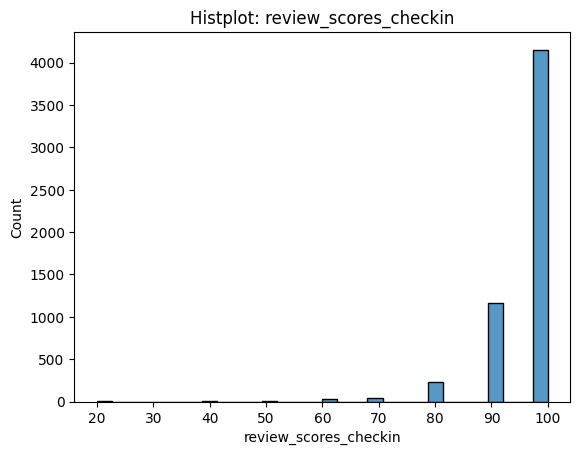

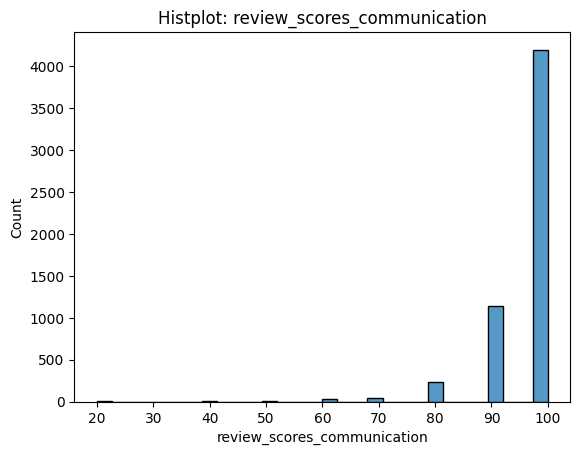

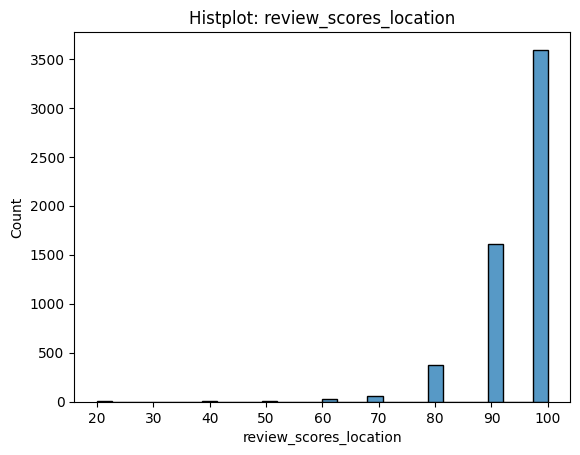

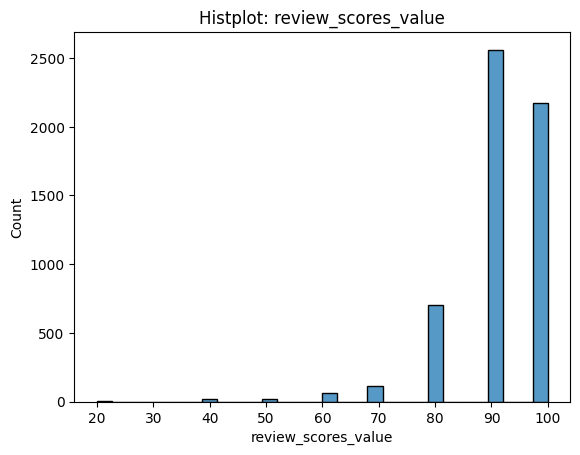

In [65]:
# Histplots de las columnas numéricas
for col in cols_num:
    sns.histplot(data=df, x = col, bins=30)
    plt.title(f'Histplot: {col}')
    plt.show()

4.2 Visualización: countplots de las columnas no numéricas (recuento por categoria)

In [54]:
# sleccionar las columnas no numéricas
cols_nonum = df.select_dtypes(include='object').columns
cols_nonum = [x for x in cols_nonum if x not in cols_excluir]

# Cuántas columnas?
print(len(cols_nonum), "columnas no numéricas para visualizar.")

7 columnas no numéricas para visualizar.


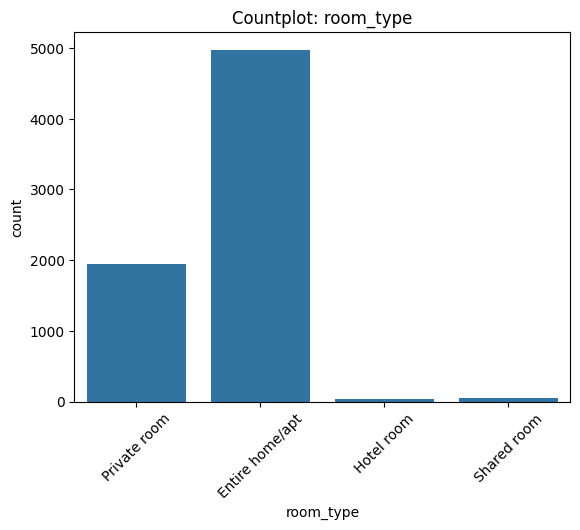

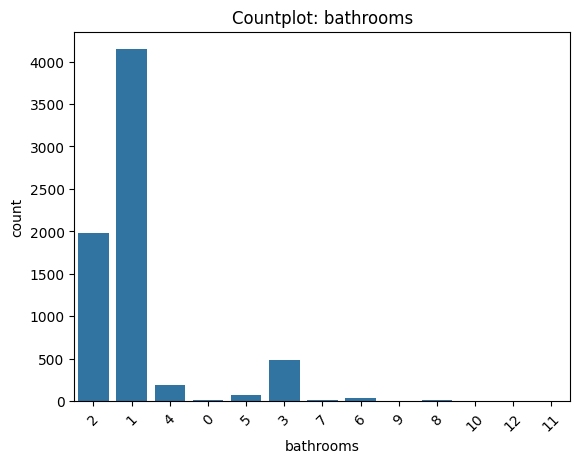

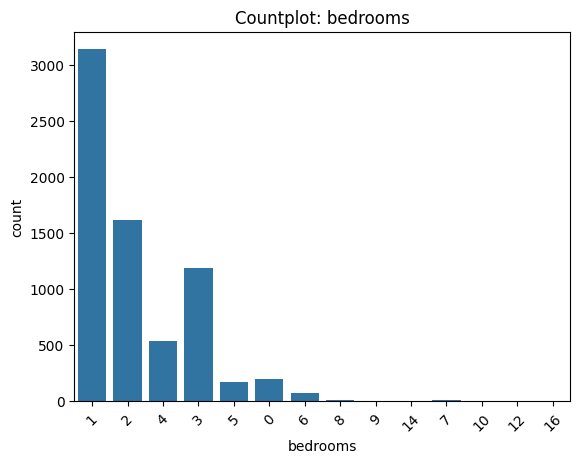

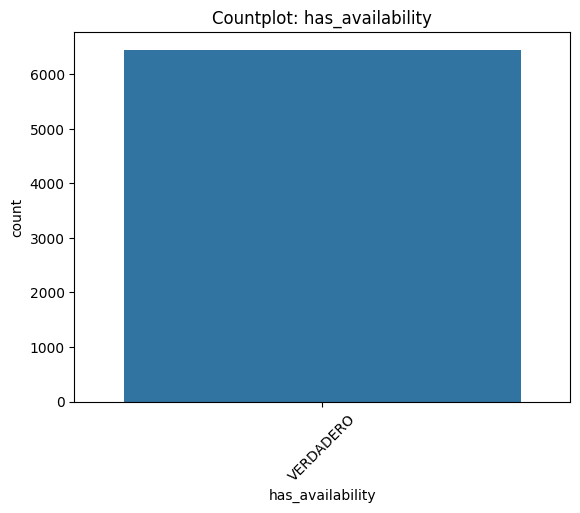

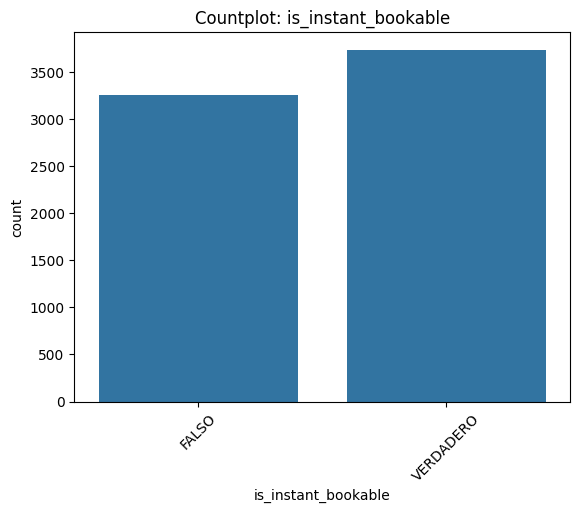

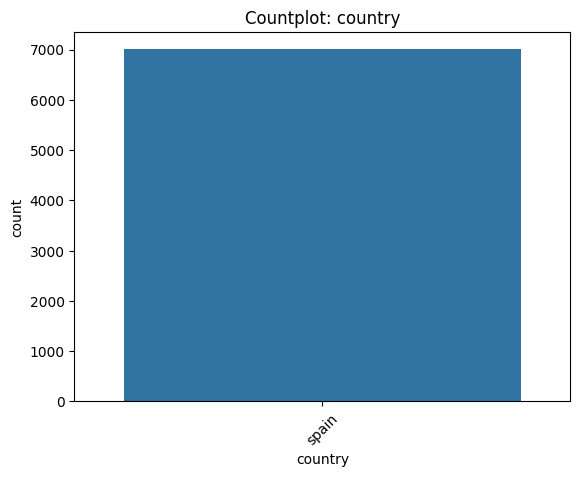

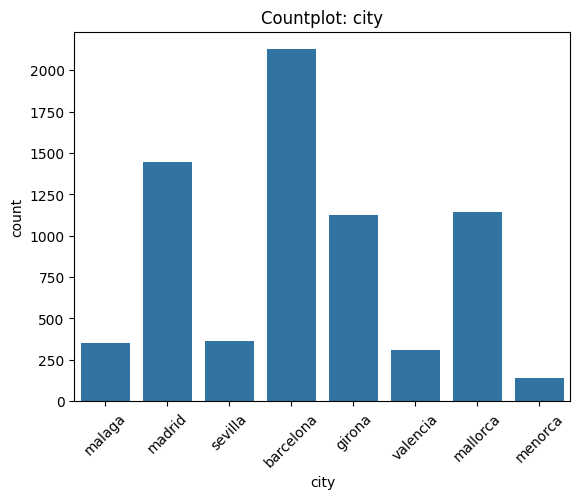

In [64]:
# Countplots de las columnas no numéricas
for col in cols_nonum:
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot: {col}')
    plt.xticks(rotation=45)
    plt.show()